# Gas Station Fuel Inventory Analysis

**Project Overview:**  
This notebook analyzes over a year of fuel purchase and sales data across 8 city gas stations.
We clean and merge five raw datasets, explore inventory patterns, assess discount utilisation,
and recommend improved replenishment policies that reduce purchasing costs without risking stock-outs.

## 1. Setup

### 1.1 Import Libraries

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import folium
from matplotlib.patches import Patch

pd.options.display.precision = 2
pd.set_option('display.float_format', '{:.2f}'.format)

### 1.2 Load Data

In [99]:
locations_df = pd.read_csv('Locations.csv')        # gas station location metadata
tanks_df     = pd.read_csv('Tanks.csv')             # tank attributes per station
invoices_df  = pd.read_csv('Invoices.csv')          # fuel purchase invoices
fuel1_df     = pd.read_csv('Fuel_Level_Part_1.csv') # fuel-level readings part 1
fuel2_df     = pd.read_csv('Fuel_Level_Part_2.csv') # fuel-level readings part 2

## 2. Data Cleaning

### 2.1 Rename Columns & Parse Dates

In [100]:
locations_df.rename(columns={
    'Gas Station Location': 'station_location', 'Gas Station Name': 'station_name',
    'Gas Station Address':  'station_address',  'Gas Station Latitude': 'station_lat',
    'Gas Station Longitude':'station_lon'}, inplace=True)

tanks_df.rename(columns={
    'Tank ID': 'tank_id', 'Tank Location': 'station_location',
    'Tank Number': 'tank_num', 'Tank Type': 'tank_type1', 'Tank Capacity': 'tank_capa'}, inplace=True)
# U (regular) and P (premium) are both grouped as Gasoline; D stays as Diesel
tanks_df['tank_type2'] = tanks_df['tank_type1'].replace({'U': 'Gasoline', 'P': 'Gasoline', 'D': 'Diesel'})

invoices_df.rename(columns={
    'Invoice Date': 'invoice_date', 'Invoice ID': 'invoice_id',
    'Invoice Gas Station Location': 'station_location', 'Gross Purchase Cost': 'purchased_cost',
    'Amount Purchased': 'purchased_amount', 'Fuel Type': 'tank_type1'}, inplace=True)
invoices_df['invoice_date'] = pd.to_datetime(invoices_df['invoice_date'])
invoices_df['tank_type2']   = invoices_df['tank_type1'].replace({'G': 'Gasoline', 'D': 'Diesel'})

fuel1_df.rename(columns={'Tank ID': 'tank_id', 'Fuel Level': 'fuel_level', 'Time stamp': 'timestamp'}, inplace=True)
fuel1_df['timestamp'] = pd.to_datetime(fuel1_df['timestamp'])

fuel2_df.columns  = fuel1_df.columns
fuel2_df['timestamp'] = pd.to_datetime(fuel2_df['timestamp'])

### 2.2 Merge Datasets & Handle Missing Values

#### `tanks_df` + `locations_df` → `tanksloc_df`

In [101]:
tanksloc_df = tanks_df.merge(locations_df, on='station_location', how='left')
tanksloc_df[tanksloc_df.isna().any(axis=1)].count()  # confirm no missing values

tank_id             0
station_location    0
tank_num            0
tank_type1          0
tank_capa           0
tank_type2          0
station_name        0
station_address     0
station_lat         0
station_lon         0
dtype: int64

#### `invoices_df` — Drop rows with missing values

In [102]:
print('invoices_df shape before:', invoices_df.shape)
invoices_df2 = invoices_df.dropna(how='any').reset_index(drop=True)
print('invoices_df shape after: ', invoices_df2.shape)

invoices_df shape before: (2873, 7)
invoices_df shape after:  (2831, 7)


#### `fuel1_df` & `fuel2_df` — Fix tank ID inconsistency, concat, drop NAs

In [103]:
print('fuel1 tank IDs before fix:', fuel1_df['tank_id'].unique())
fuel1_df.loc[fuel1_df['tank_id'] == 'T12', 'tank_id'] = 'T 12'
print('fuel1 tank IDs after fix: ', fuel1_df['tank_id'].unique())

fuel_df = pd.concat([fuel1_df, fuel2_df], ignore_index=True)
fuel_df = fuel_df.dropna(how='any').reset_index(drop=True)

fuel1 tank IDs before fix: ['T 12' 'T12' 'T 13' 'T 15' 'T 17' 'T 19' 'T 21' 'T 23' 'T 24' 'T 28'
 'T 30' 'T 31']
fuel1 tank IDs after fix:  ['T 12' 'T 13' 'T 15' 'T 17' 'T 19' 'T 21' 'T 23' 'T 24' 'T 28' 'T 30'
 'T 31']


#### `fuel_df` + `tanksloc_df` → `fueltank_df`

In [104]:
fueltank_df = fuel_df.merge(
    tanksloc_df[['tank_id', 'station_location', 'tank_num', 'tank_type2', 'tank_capa', 'station_name']],
    on='tank_id', how='left')
fueltank_df.head()

,tank_id,fuel_level,timestamp,station_location,tank_num,tank_type2,tank_capa,station_name
0,T 12,27161.00,2017-01-01 00:10:00,1,3,Diesel,40000,EastMount
1,T 12,27017.00,2017-01-01 00:25:00,1,3,Diesel,40000,EastMount
2,T 12,26934.00,2017-01-01 00:40:00,1,3,Diesel,40000,EastMount
3,T 12,26786.00,2017-01-01 00:55:00,1,3,Diesel,40000,EastMount
4,T 12,26748.00,2017-01-01 01:10:00,1,3,Diesel,40000,EastMount


### 2.3 Add Derived Columns

In [105]:
# invoices: date parts and computed metrics
invoices_df2['Year']            = invoices_df2['invoice_date'].dt.year
invoices_df2['Month']           = invoices_df2['invoice_date'].dt.month
invoices_df2['Day']             = invoices_df2['invoice_date'].dt.day
invoices_df2['Day_dig']         = invoices_df2['invoice_date'].dt.dayofweek  # 0=Monday
invoices_df2['Weekday']         = invoices_df2['invoice_date'].dt.day_name()
invoices_df2['price_per_liter'] = invoices_df2['purchased_cost'] / invoices_df2['purchased_amount']

# fueltank: date parts and fuel-level percentage
fueltank_df['date']           = fueltank_df['timestamp'].dt.date
fueltank_df['year']           = fueltank_df['timestamp'].dt.year
fueltank_df['month']          = fueltank_df['timestamp'].dt.month
fueltank_df['day']            = fueltank_df['timestamp'].dt.day
fueltank_df['day_dig']        = fueltank_df['timestamp'].dt.dayofweek
fueltank_df['weekday']        = fueltank_df['timestamp'].dt.day_name()
fueltank_df['fuel_level_per'] = fueltank_df['fuel_level'] / fueltank_df['tank_capa']

## 3. Data Exploration

### 3.1 Map of Gas Stations

In [106]:
tanksloc_df['station_num_name'] = tanksloc_df['station_location'].astype(str) + '_' + tanksloc_df['station_name']
tank_map = (tanksloc_df[['station_num_name', 'station_lat', 'station_lon']]
            .value_counts().reset_index().rename(columns={'count': 'tank_cnt'}))

m = folium.Map(location=[tank_map['station_lat'].mean(), tank_map['station_lon'].mean()], zoom_start=10)
for _, row in tank_map.iterrows():
    folium.Marker(
        location=[row['station_lat'], row['station_lon']],
        popup=f"{row['station_num_name']} | Tanks: {row['tank_cnt']}",
        tooltip='Click to see station name and tank count'
    ).add_to(m)

m.save('gas_station_map.html')
print("Map saved as gas_station_map.html — open in a browser to view the interactive map.")
m

Map saved as gas_station_map.html — open in a browser to view the interactive map.


### 3.2 Tank Capacity by Tank ID

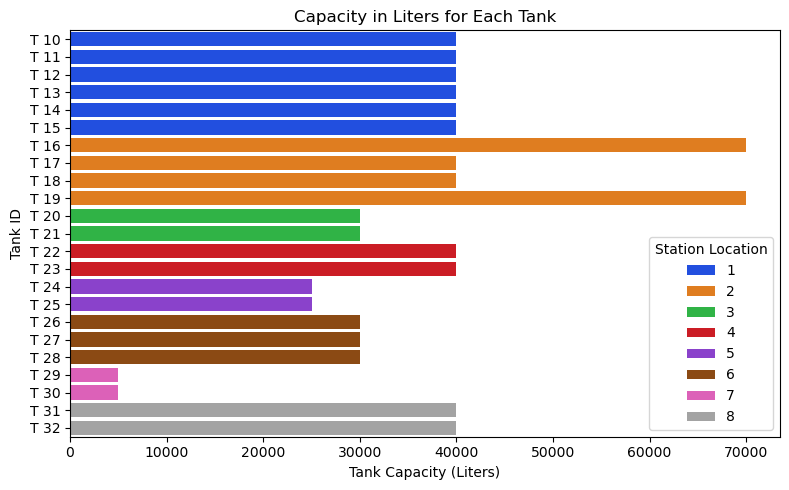

In [142]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=tanksloc_df, x='tank_capa', y='tank_id', hue='station_location',
            palette='bright', ax=ax, native_scale=False)
ax.set(xlabel='Tank Capacity (Liters)', ylabel='Tank ID', title='Capacity in Liters for Each Tank')
ax.legend(title='Station Location')
plt.tight_layout()
plt.show()

### 3.3 Tank Capacities by Station, Fuel Type, and Tank ID

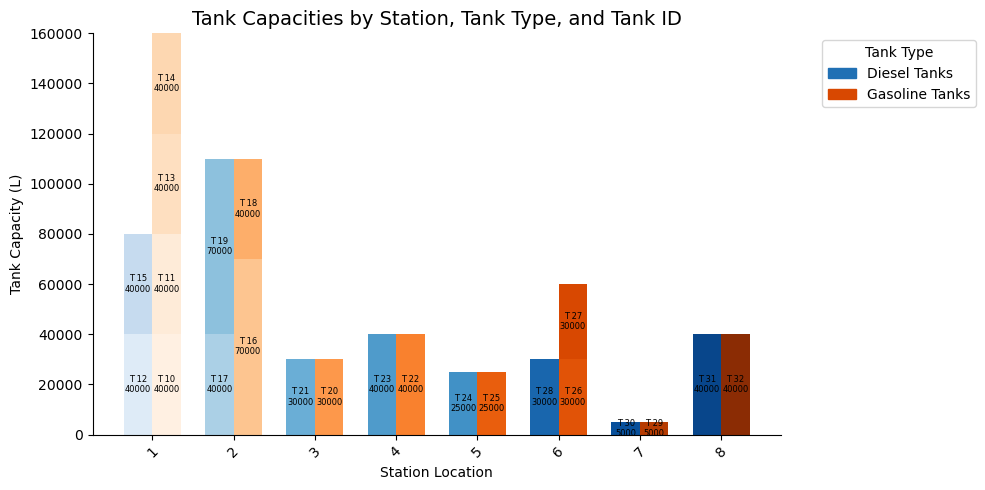

In [108]:
tank_summary = (tanksloc_df
    .groupby(['station_location', 'tank_type2', 'tank_id'], as_index=False)['tank_capa'].sum())
pivot_df = tank_summary.pivot_table(
    index=['station_location', 'tank_type2'], columns='tank_id', values='tank_capa', fill_value=0)

station_locs    = pivot_df.index.get_level_values('station_location').unique()
tank_types      = pivot_df.index.get_level_values('tank_type2').unique()
bar_width       = 0.35
x               = np.arange(len(station_locs))
diesel_colors   = sns.color_palette('Blues',   n_colors=len(pivot_df.columns))
gasoline_colors = sns.color_palette('Oranges', n_colors=len(pivot_df.columns))

fig, ax = plt.subplots(figsize=(10, 5))
for i, ttype in enumerate(tank_types):
    sub    = pivot_df.loc[pivot_df.index.get_level_values('tank_type2') == ttype].reindex(station_locs, level=0)
    bottom = np.zeros(len(station_locs))
    colors = diesel_colors if 'diesel' in ttype.lower() else gasoline_colors
    for color, tank_id in zip(colors, sub.columns):
        bars = ax.bar(x + i * bar_width, sub[tank_id], bar_width, bottom=bottom, color=color, edgecolor='none')
        for bar in bars:
            if bar.get_height() > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                        f'{tank_id}\n{int(bar.get_height())}', ha='center', va='center', fontsize=6)
        bottom += sub[tank_id].values

ax.set_title('Tank Capacities by Station, Tank Type, and Tank ID', fontsize=14)
ax.set_xlabel('Station Location')
ax.set_ylabel('Tank Capacity (L)')
ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(station_locs, rotation=45)
ax.legend(handles=[
    Patch(color=sns.color_palette('Blues',   3)[2], label='Diesel Tanks'),
    Patch(color=sns.color_palette('Oranges', 3)[2], label='Gasoline Tanks')
], title='Tank Type', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

### 3.4 Invoice Count by Station and Fuel Type

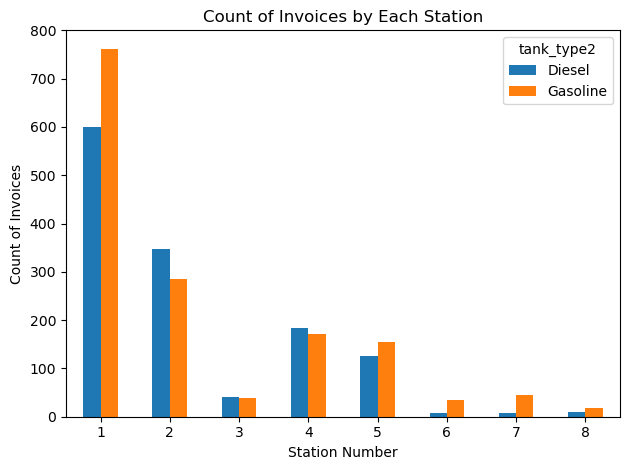

In [109]:
invoices_df2.pivot_table(
    index='station_location', columns='tank_type2', values='invoice_id', aggfunc='count'
).plot(kind='bar', xlabel='Station Number', ylabel='Count of Invoices',
       title='Count of Invoices by Each Station', rot=0)
plt.tight_layout()
plt.show()

### 3.5 Average Order Interval by Station

In [110]:
invoice_freq = (invoices_df2
    .groupby(['station_location', 'tank_type2', 'invoice_date', 'Weekday'])['invoice_id']
    .count().reset_index())
invoice_freq['lead_day'] = (invoice_freq
    .groupby(['station_location', 'tank_type2'])['invoice_date'].diff().dt.days)

# Table: avg days between orders per station x fuel type
invoice_freq.pivot_table(
    index='station_location', columns='tank_type2', values='lead_day', aggfunc='mean'
).sort_values(by='Gasoline')

tank_type2,Diesel,Gasoline
station_location,,
1,2.13,1.78
4,5.24,5.56
2,4.24,5.81
5,7.65,6.20
7,94.57,21.37
3,19.60,23.39
6,140.83,31.62
8,97.00,49.28


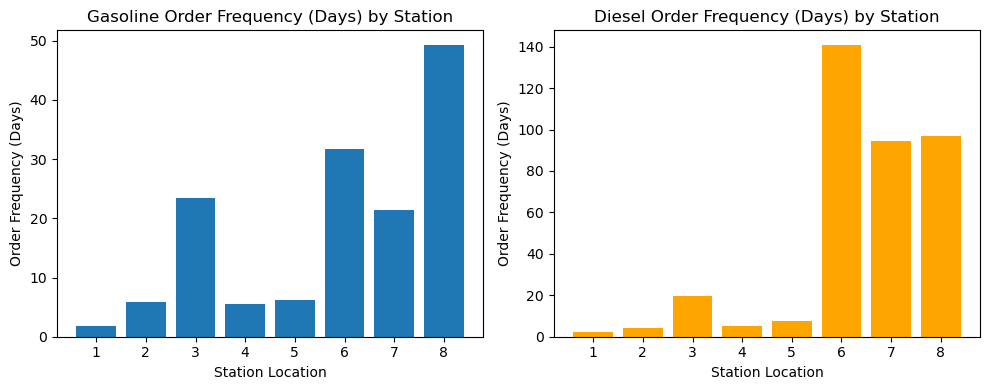

In [111]:
invoice_freq_g = invoice_freq.query("tank_type2 == 'Gasoline'").groupby('station_location')['lead_day'].mean().reset_index()
invoice_freq_d = invoice_freq.query("tank_type2 == 'Diesel'").groupby('station_location')['lead_day'].mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(invoice_freq_g['station_location'], invoice_freq_g['lead_day'])
ax[0].set(xlabel='Station Location', ylabel='Order Frequency (Days)',
          title='Gasoline Order Frequency (Days) by Station')
ax[1].bar(invoice_freq_d['station_location'], invoice_freq_d['lead_day'], color='orange')
ax[1].set(xlabel='Station Location', ylabel='Order Frequency (Days)',
          title='Diesel Order Frequency (Days) by Station')
plt.tight_layout()
plt.show()

### 3.6 Invoice Count by Day of Week

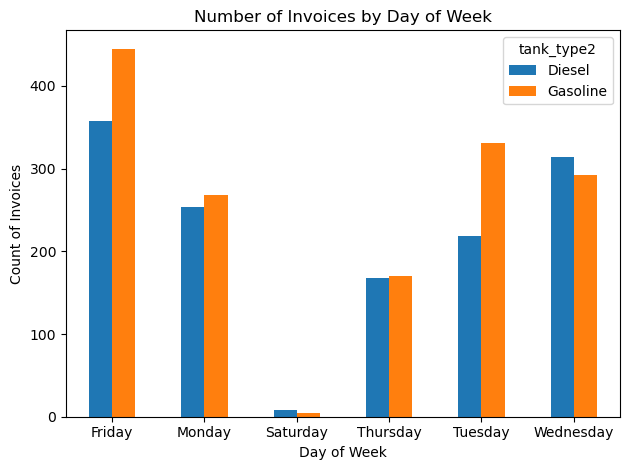

In [112]:
invoices_df2.pivot_table(
    index='Weekday', columns='tank_type2', values='invoice_id', aggfunc='count'
).plot(kind='bar', xlabel='Day of Week', ylabel='Count of Invoices',
       title='Number of Invoices by Day of Week', rot=0)
plt.tight_layout()
plt.show()

## 4. Fuel Level / Inventory Patterns by Station

### 4.1 Fuel Level Over Time by Tank
*Red dashed line = 50% capacity safety stock threshold*

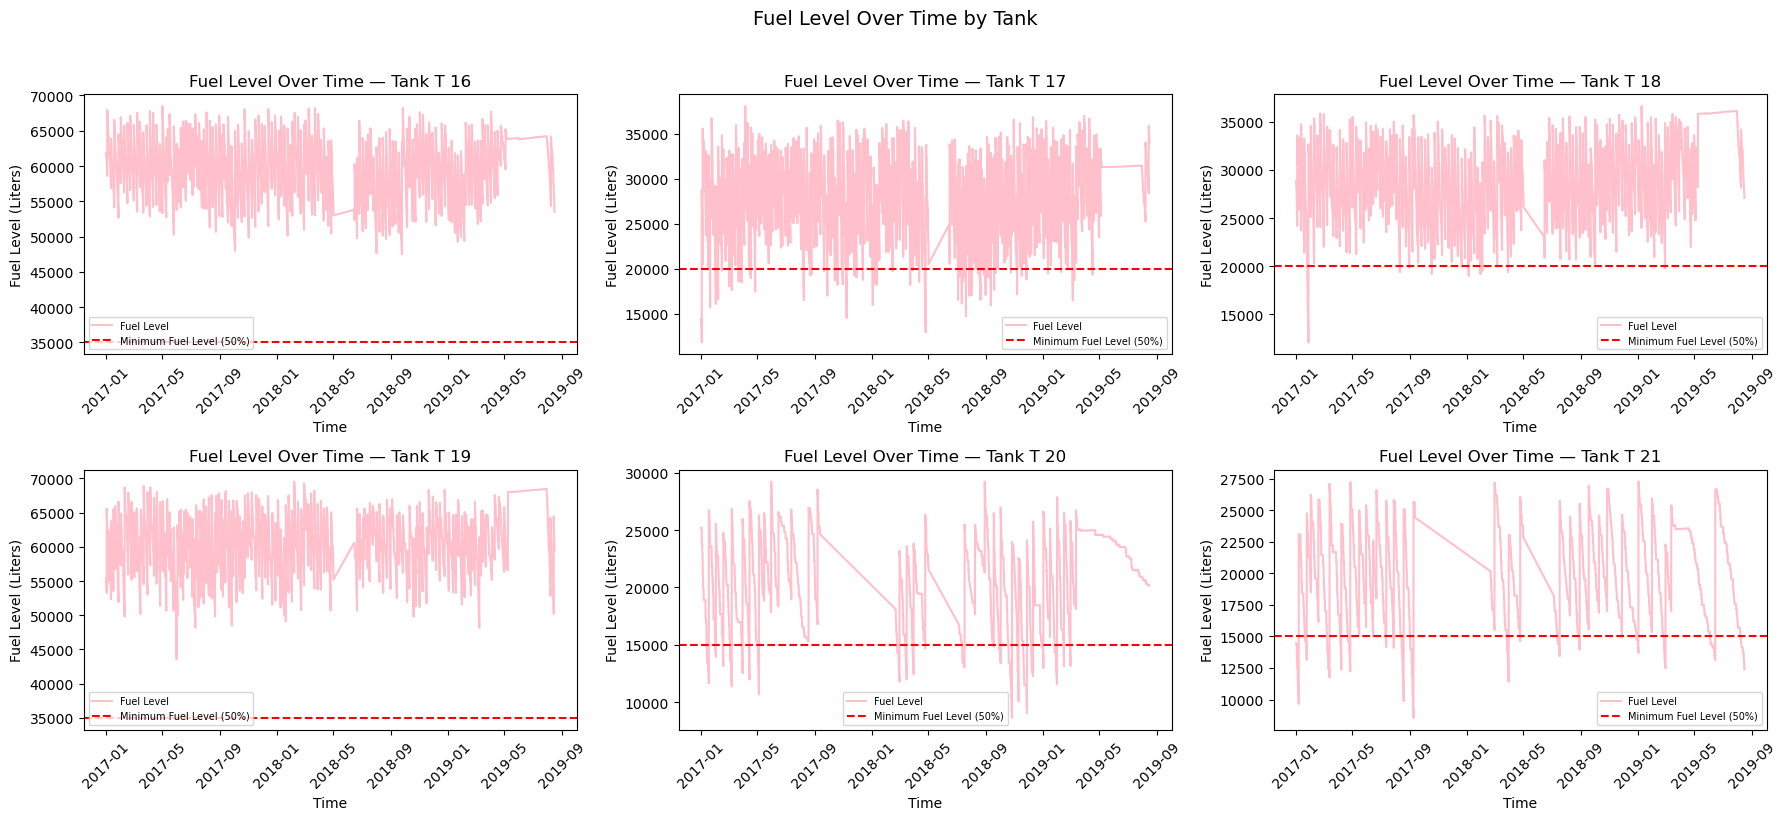

In [113]:
tank_ids = ['T 16', 'T 17', 'T 18', 'T 19', 'T 20', 'T 21']
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for ax, tank_id in zip(axes.flatten(), tank_ids):
    df            = fueltank_df[fueltank_df['tank_id'] == tank_id]
    tank_capacity = df['tank_capa'].iloc[0]
    sns.lineplot(data=df, x='timestamp', y='fuel_level', color='pink',
                 linewidth=1.5, label='Fuel Level', ax=ax)
    ax.axhline(y=tank_capacity * 0.5, color='red', linestyle='--',
               linewidth=1.5, label='Minimum Fuel Level (50%)')
    ax.set_title(f'Fuel Level Over Time — Tank {tank_id}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Fuel Level (Liters)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7)

plt.suptitle('Fuel Level Over Time by Tank', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Total Tank Capacity & Maximum Achievable Discount per Station

In [114]:
capacity_summary = (tanks_df
    .groupby(['station_location', 'tank_type1'])['tank_capa'].sum()
    .reset_index().rename(columns={'tank_capa': 'total_capacity'}))

def discount_per_liter(capacity: float) -> int:
    """Return supplier discount in cents/L based on order quantity tiers."""
    if capacity <= 15_000: return 0
    elif capacity <= 25_000: return 2
    elif capacity <= 40_000: return 3
    return 4

capacity_summary['discount_cents_per_liter'] = capacity_summary['total_capacity'].apply(discount_per_liter)
station_discount = (capacity_summary
    .groupby(['station_location', 'tank_type1'])['discount_cents_per_liter'].max()
    .reset_index().rename(columns={'discount_cents_per_liter': 'max_discount_cents'}))
station_discount.sort_values(by='max_discount_cents', ascending=False)

,station_location,tank_type1,max_discount_cents
0,1,D,4
2,1,U,4
3,2,D,4
4,2,U,4
12,6,U,4
1,1,P,3
15,8,D,3
11,6,D,3
8,4,U,3
7,4,D,3


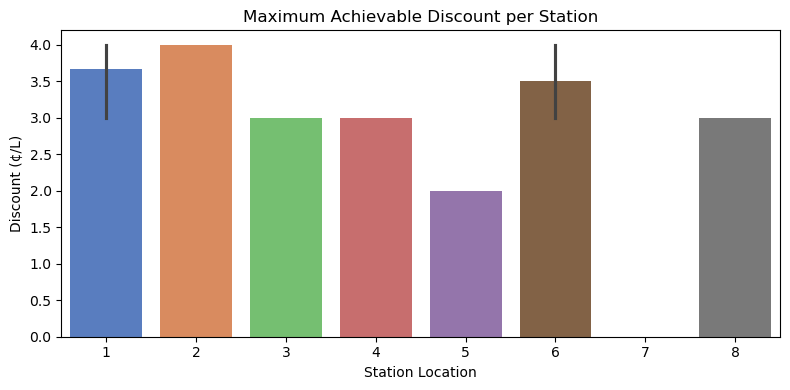

In [115]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(8, 4))
sns.barplot(data=station_discount, x='station_location', y='max_discount_cents', palette='muted')
plt.title('Maximum Achievable Discount per Station')
plt.xlabel('Station Location')
plt.ylabel('Discount (¢/L)')
plt.tight_layout()
plt.show()

## 5. Inventory Replenishment Patterns

### 5.1 Monthly Fuel Purchased by Fuel Type

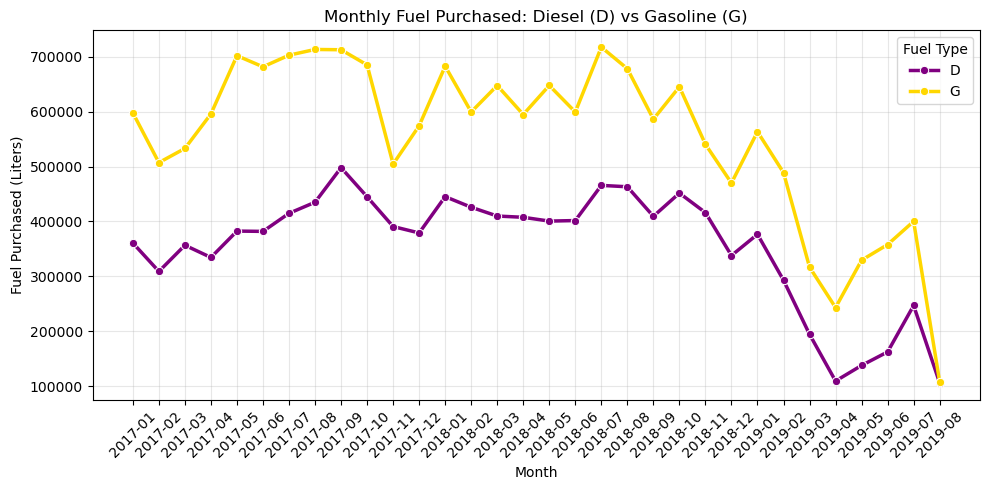

In [116]:
invoices_df2['year_month'] = invoices_df2['invoice_date'].dt.to_period('M').astype(str)
purchase_df = invoices_df2.groupby(['year_month', 'tank_type1'])['purchased_amount'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=purchase_df, x='year_month', y='purchased_amount', hue='tank_type1',
             palette={'D': 'purple', 'G': 'gold'}, linewidth=2.5, marker='o')
plt.title('Monthly Fuel Purchased: Diesel (D) vs Gasoline (G)')
plt.xlabel('Month')
plt.ylabel('Fuel Purchased (Liters)')
plt.xticks(rotation=45)
plt.legend(title='Fuel Type', loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Are Stations Capturing the Maximum Volume Discount?

In [117]:
def disc_per(quantity: float) -> float:
    """Return supplier discount in CAD/L based on purchase quantity tiers."""
    if quantity <= 15_000: return 0.00
    elif quantity <= 25_000: return 0.02
    elif quantity <= 40_000: return 0.03
    return 0.04

invoices_df2['disc_per_liter'] = invoices_df2['purchased_amount'].apply(disc_per)
invoices_df2['disc_total']     = invoices_df2['purchased_amount'] * invoices_df2['disc_per_liter']

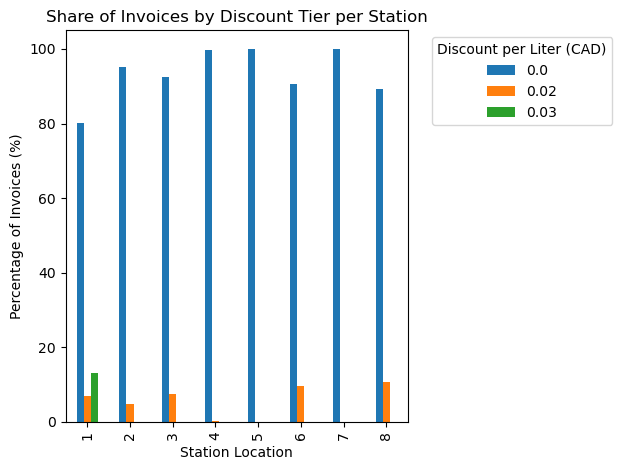

In [118]:
# Share of invoices per discount tier by station
axes = pd.crosstab(invoices_df2['station_location'], invoices_df2['disc_per_liter'],
                   normalize='index').mul(100).plot(kind='bar')
axes.set(xlabel='Station Location', ylabel='Percentage of Invoices (%)',
         title='Share of Invoices by Discount Tier per Station')
axes.legend(title='Discount per Liter (CAD)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

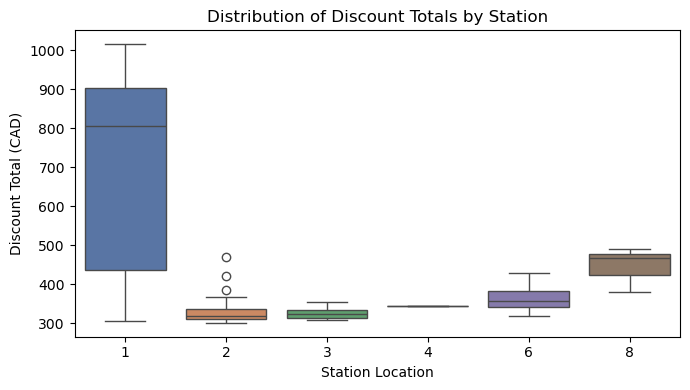

In [119]:
# Distribution of discount totals for invoices that earned a discount
plt.figure(figsize=(7, 4))
sns.boxplot(data=invoices_df2.query('disc_total > 0'),
            x='station_location', y='disc_total', palette='deep')
plt.title('Distribution of Discount Totals by Station')
plt.xlabel('Station Location')
plt.ylabel('Discount Total (CAD)')
plt.tight_layout()
plt.show()

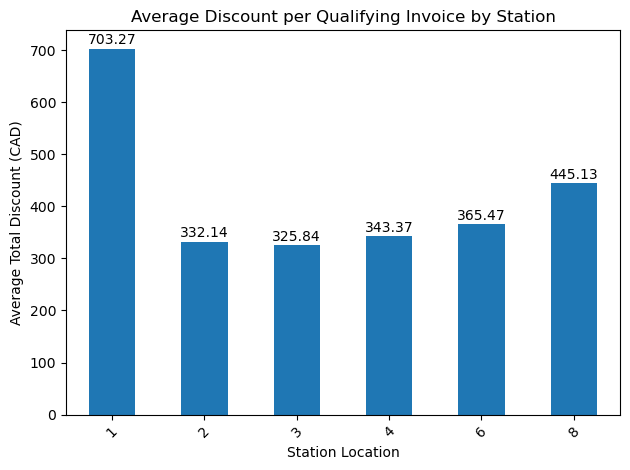

In [120]:
# Average discount per qualifying invoice by station
avg_disc = invoices_df2.query('disc_per_liter > 0').groupby('station_location')['disc_total'].mean()
ax = avg_disc.plot(kind='bar')
plt.title('Average Discount per Qualifying Invoice by Station')
plt.xlabel('Station Location')
plt.ylabel('Average Total Discount (CAD)')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=1)
plt.tight_layout()
plt.show()

In [121]:
# Maximum discount each station could receive if ordering a full tank fill
station_capa_df = (tanksloc_df
    .groupby(['station_location', 'tank_type2'])['tank_capa']
    .agg(total_capa='sum', tank_cnt='count').reset_index())
station_capa_df['disc_per_liter']  = station_capa_df['total_capa'].apply(disc_per)
station_capa_df['min_level']       = station_capa_df['total_capa'] * 0.5
station_capa_df['disc_max']        = station_capa_df['disc_per_liter'] * station_capa_df['total_capa']
station_capa_df['disc_per_liter2'] = station_capa_df['min_level'].apply(disc_per)
station_capa_df['disc_min_max']    = station_capa_df['disc_per_liter'] * station_capa_df['min_level']
station_capa_df

,station_location,tank_type2,total_capa,tank_cnt,disc_per_liter,min_level,disc_max,disc_per_liter2,disc_min_max
0,1,Diesel,80000,2,0.04,40000.00,3200.00,0.03,1600.00
1,1,Gasoline,160000,4,0.04,80000.00,6400.00,0.04,3200.00
2,2,Diesel,110000,2,0.04,55000.00,4400.00,0.04,2200.00
3,2,Gasoline,110000,2,0.04,55000.00,4400.00,0.04,2200.00
4,3,Diesel,30000,1,0.03,15000.00,900.00,0.00,450.00
5,3,Gasoline,30000,1,0.03,15000.00,900.00,0.00,450.00
6,4,Diesel,40000,1,0.03,20000.00,1200.00,0.02,600.00
7,4,Gasoline,40000,1,0.03,20000.00,1200.00,0.02,600.00
8,5,Diesel,25000,1,0.02,12500.00,500.00,0.00,250.00
9,5,Gasoline,25000,1,0.02,12500.00,500.00,0.00,250.00


In [122]:
avg_disc = invoices_df2.groupby(['station_location', 'tank_type2'])['disc_total'].mean().sort_index()
avg_disc

station_location  tank_type2
1                 Diesel         3.92
                  Gasoline     247.03
2                 Diesel        19.49
                  Gasoline      12.40
3                 Diesel         7.79
                  Gasoline      41.94
4                 Diesel         1.87
                  Gasoline       0.00
5                 Diesel         0.00
                  Gasoline       0.00
6                 Diesel         0.00
                  Gasoline      41.77
7                 Diesel         0.00
                  Gasoline       0.00
8                 Diesel        54.34
                  Gasoline      44.54
Name: disc_total, dtype: float64

### 5.3 Do Stations Adjust Order Quantity When Prices Fluctuate?

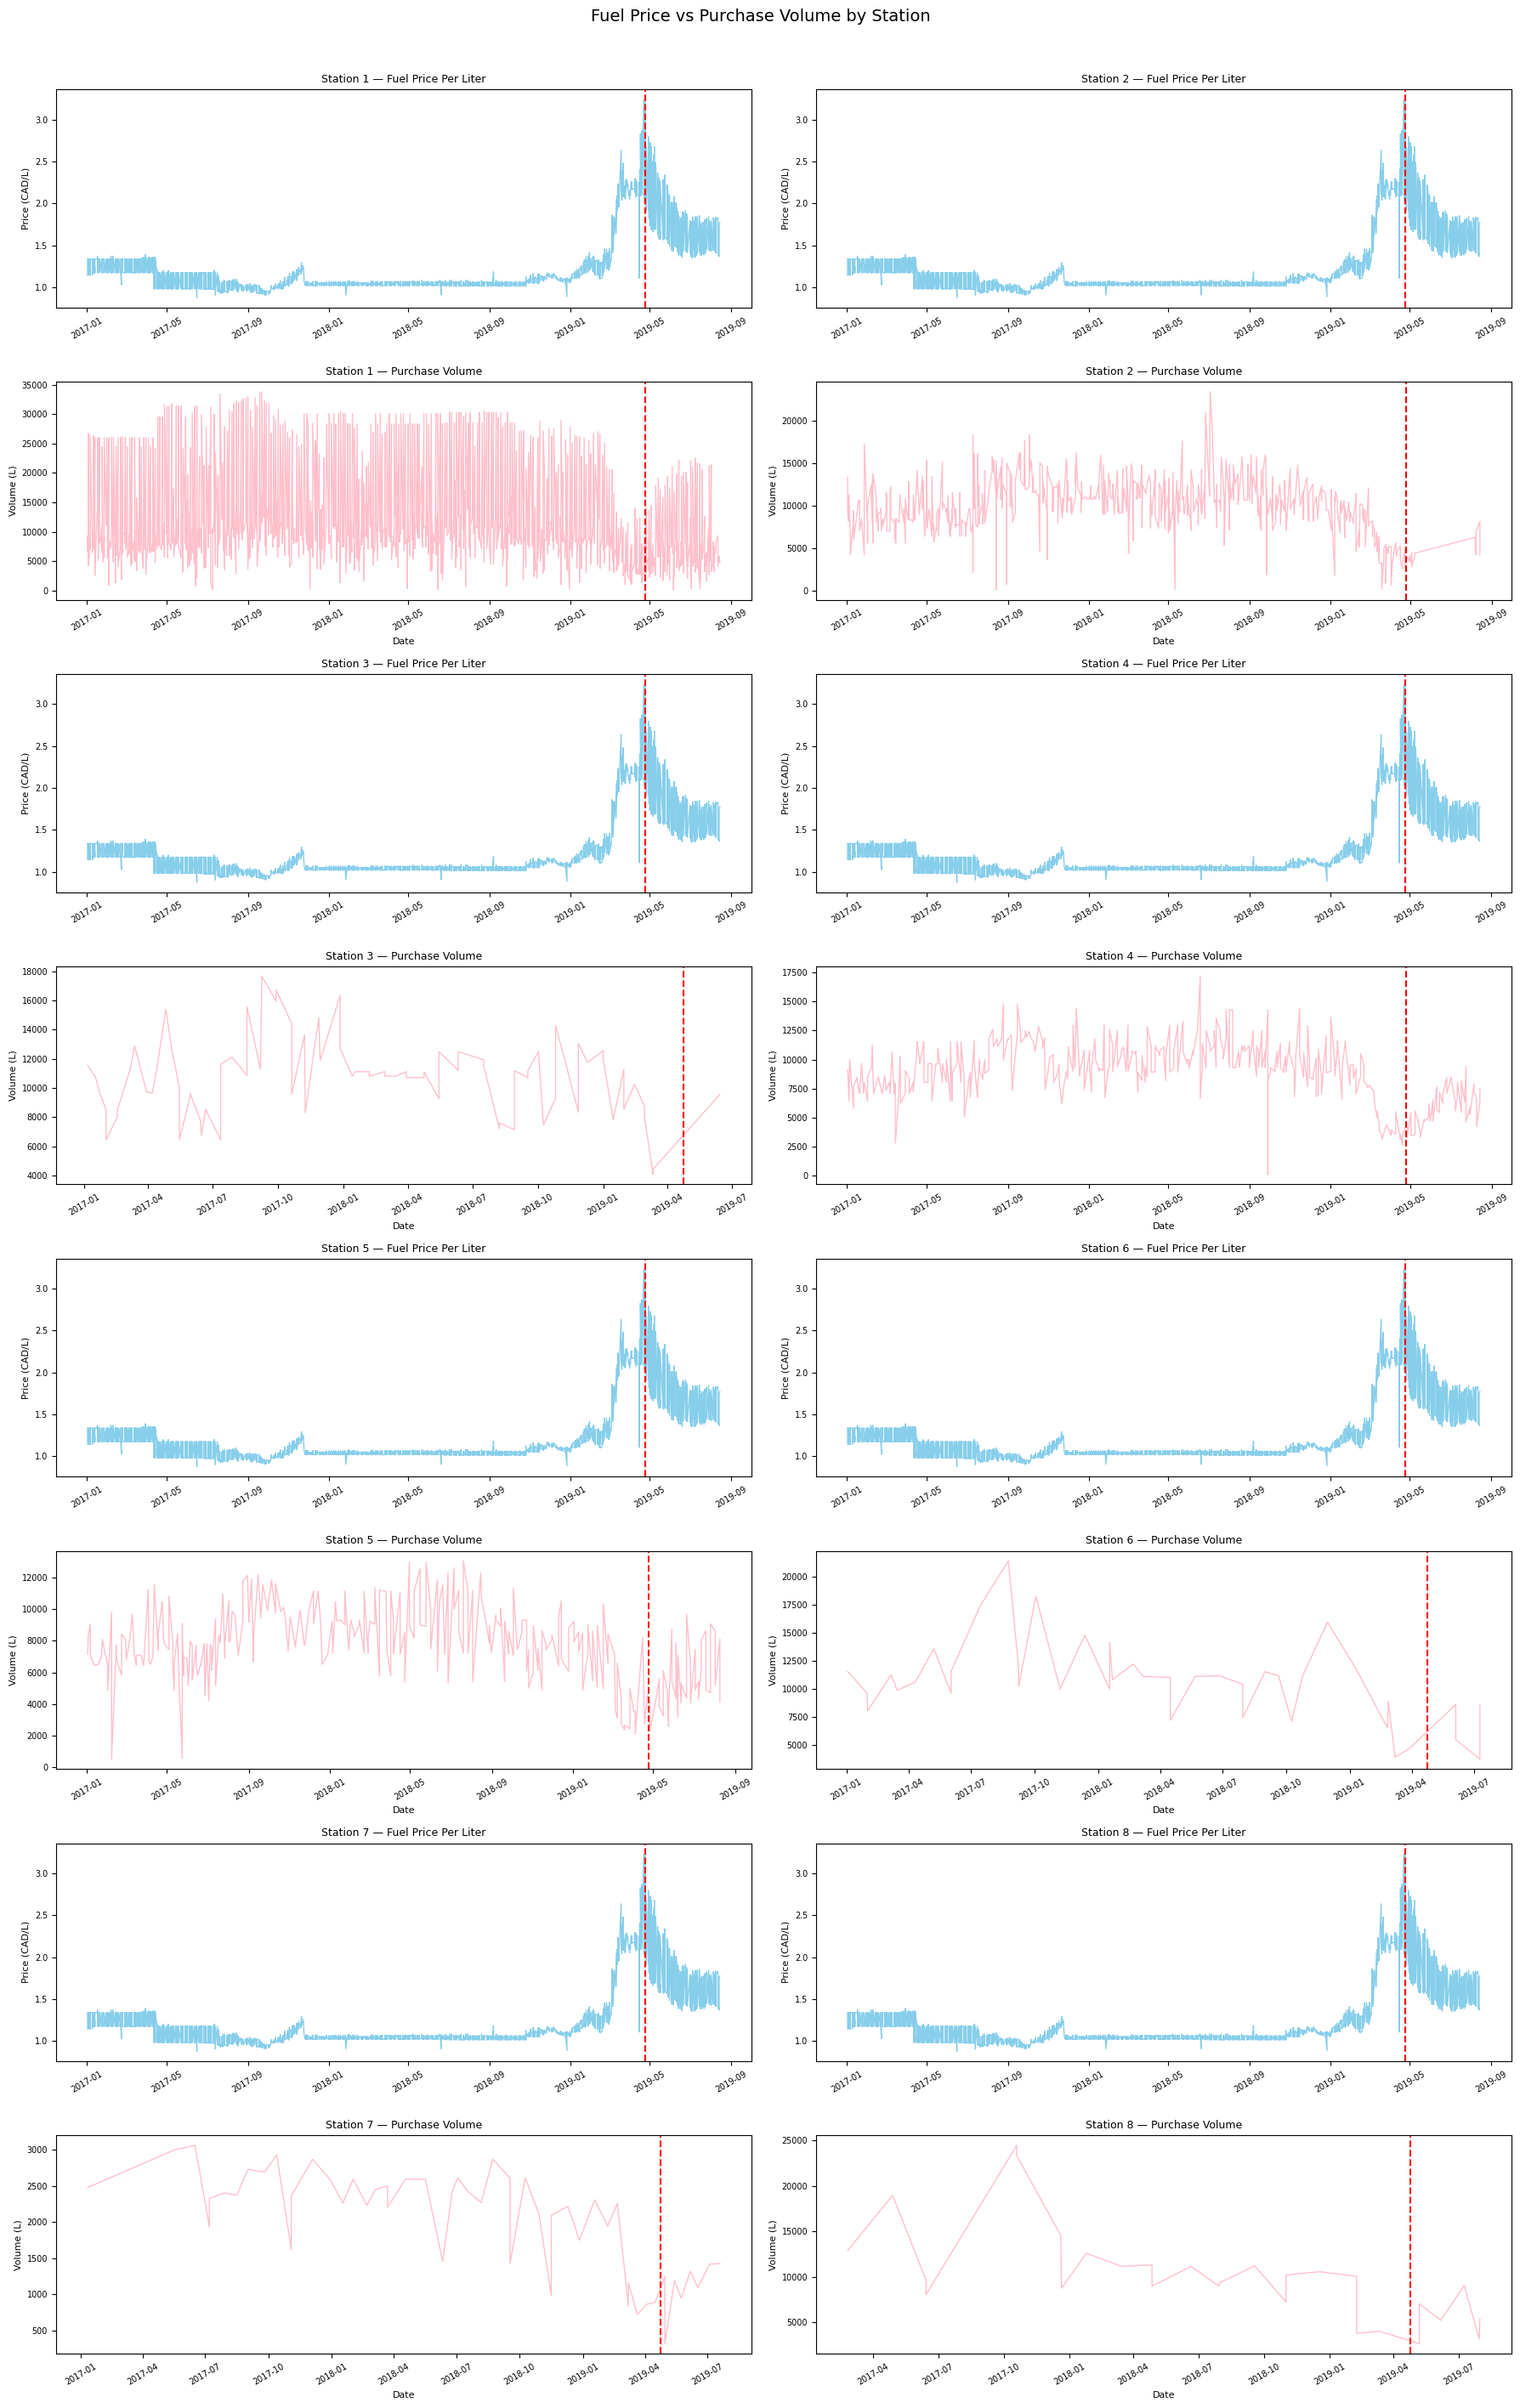

In [123]:
# Price vs purchase volume per station — 2 columns, price repeated above each station
peak_price_date = invoices_df2.loc[invoices_df2['price_per_liter'].idxmax(), 'invoice_date']

fig, axes = plt.subplots(8, 2, figsize=(18, 28))

for sid in range(1, 9):
    row = (sid - 1) // 2 * 2
    col = (sid - 1) % 2

    ax_price = axes[row, col]
    ax_price.plot(invoices_df2['invoice_date'], invoices_df2['price_per_liter'],
                  color='skyblue', linewidth=1)
    ax_price.axvline(x=peak_price_date, color='red', linestyle='--', linewidth=1.5)
    ax_price.set_title(f'Station {sid} — Fuel Price Per Liter', fontsize=9)
    ax_price.set_ylabel('Price (CAD/L)', fontsize=8)
    ax_price.tick_params(axis='x', rotation=30, labelsize=7)
    ax_price.tick_params(axis='y', labelsize=7)

    ax_vol = axes[row + 1, col]
    station_data = invoices_df2.loc[invoices_df2['station_location'] == sid]
    ax_vol.plot(station_data['invoice_date'], station_data['purchased_amount'],
                color='pink', linewidth=1)
    ax_vol.axvline(x=peak_price_date, color='red', linestyle='--', linewidth=1.5)
    ax_vol.set_title(f'Station {sid} — Purchase Volume', fontsize=9)
    ax_vol.set_ylabel('Volume (L)', fontsize=8)
    ax_vol.set_xlabel('Date', fontsize=8)
    ax_vol.tick_params(axis='x', rotation=30, labelsize=7)
    ax_vol.tick_params(axis='y', labelsize=7)

plt.suptitle('Fuel Price vs Purchase Volume by Station', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Monthly Purchase Frequency by Station and Year

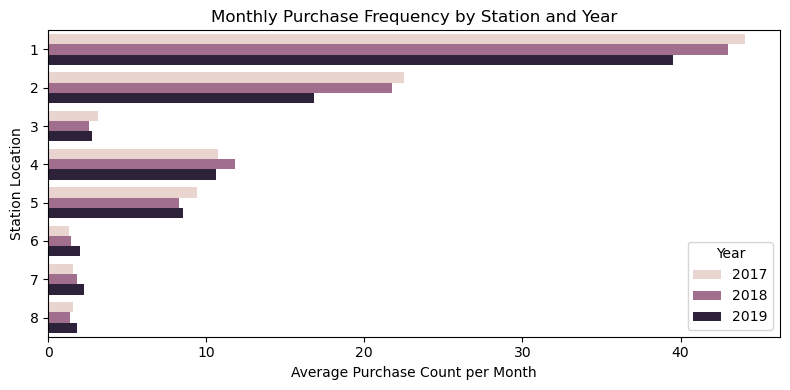

In [124]:
frequency = invoices_df2.pivot_table(
    index=['Year', 'station_location'], columns='Month', values='invoice_id', aggfunc='count')
frequency['avg_times'] = frequency.mean(axis=1)

plt.figure(figsize=(8, 4))
sns.barplot(data=frequency.reset_index(), x='avg_times', y='station_location',
            hue='Year', orient='h', errorbar=None)
plt.title('Monthly Purchase Frequency by Station and Year')
plt.xlabel('Average Purchase Count per Month')
plt.ylabel('Station Location')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

## 6. Improved Inventory Policy Recommendations

### 6.1 Cost Saving Potential from Quantity-Discount Optimisation

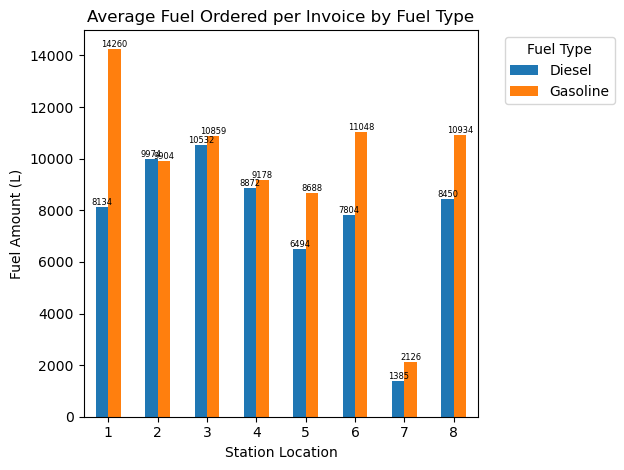

In [125]:
# Average fuel ordered per invoice by station and fuel type
axes = invoices_df2.pivot_table(
    index='station_location', columns='tank_type2', values='purchased_amount', aggfunc='mean'
).plot(kind='bar', xlabel='Station Location', ylabel='Fuel Amount (L)',
       title='Average Fuel Ordered per Invoice by Fuel Type', rot=0)
axes.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
for container in axes.containers:
    axes.bar_label(container, fmt='%.0f', label_type='edge', fontsize=6)
plt.tight_layout()
plt.show()

In [126]:
# Calculate daily fuel consumption using first/last reading per tank per day
fueltank_df.loc[fueltank_df.groupby(['tank_id', 'date']).head(1).index, 'entry_type'] = 'first'
fueltank_df.loc[fueltank_df.groupby(['tank_id', 'date']).tail(1).index, 'entry_type'] = 'last'

fuel_first_last = (fueltank_df.query('entry_type.notna()')
    [['tank_id', 'fuel_level', 'timestamp', 'station_location', 'tank_type2',
      'tank_capa', 'fuel_level_per', 'date', 'weekday', 'entry_type']]
    .reset_index(drop=True))
fuel_first_last['diff']      = fuel_first_last.groupby(['tank_id', 'date'])['fuel_level'].diff()
fuel_first_last['min_level'] = fuel_first_last['tank_capa'] * 0.5

fuel_dec         = fuel_first_last.query('diff < 0').copy()
fuel_dec['diff'] = fuel_dec['diff'].abs()

fuel_avg  = (fuel_dec
    .groupby(['station_location', 'tank_id', 'tank_type2', 'tank_capa', 'min_level'], as_index=False)['diff']
    .mean().rename(columns={'diff': 'avg_daily_consumption'}))
fuel_dec2 = (fuel_first_last.query('diff < 0')
    .groupby(['tank_id', 'tank_type2', 'min_level'], as_index=False)['diff'].mean())
fuel_dec2['avg_daily_consumption'] = fuel_dec2['diff'].abs()
fuel_dec2['day_to_min']            = fuel_dec2['min_level'] / fuel_dec2['avg_daily_consumption']

combined = (fuel_avg
    .merge(fuel_dec2[['tank_id', 'day_to_min']], on='tank_id', how='left')
    .sort_values('avg_daily_consumption', ascending=False))

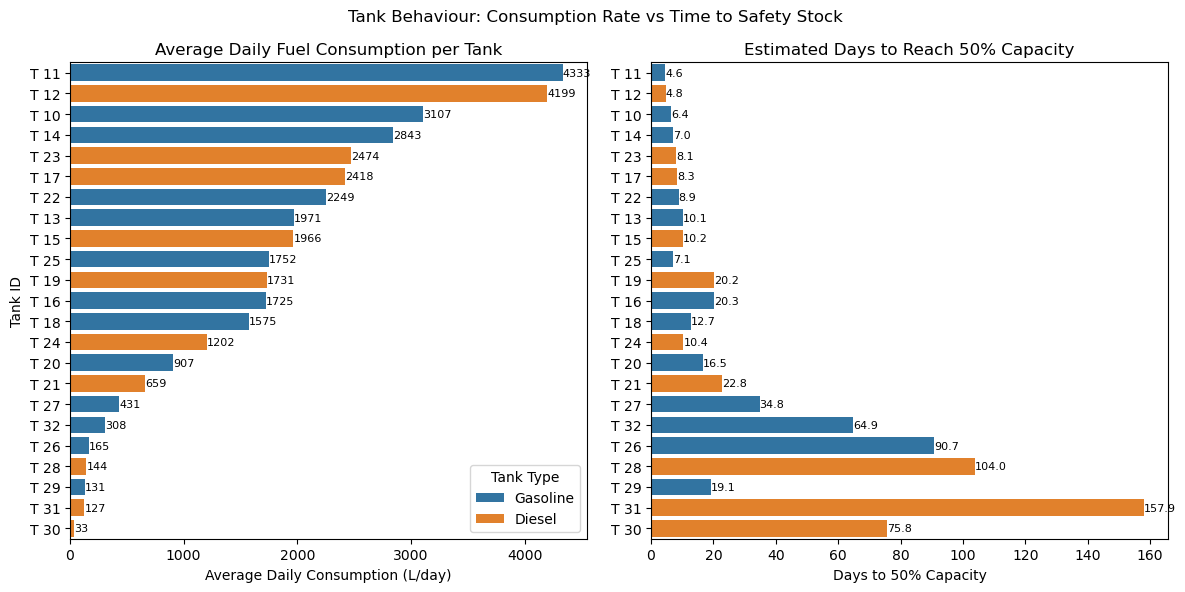

In [127]:
# Side-by-side: avg daily consumption and days to 50% capacity
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.barplot(data=combined, y='tank_id', x='avg_daily_consumption',
            hue='tank_type2', dodge=False, ax=axes[0])
axes[0].set_title('Average Daily Fuel Consumption per Tank')
axes[0].set_xlabel('Average Daily Consumption (L/day)')
axes[0].set_ylabel('Tank ID')
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.0f', label_type='edge', fontsize=8)
axes[0].legend(title='Tank Type', loc='lower right')

sns.barplot(data=combined, y='tank_id', x='day_to_min',
            hue='tank_type2', dodge=False, ax=axes[1])
axes[1].set_title('Estimated Days to Reach 50% Capacity')
axes[1].set_xlabel('Days to 50% Capacity')
axes[1].set_ylabel('')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f', label_type='edge', fontsize=8)
axes[1].get_legend().remove()

plt.suptitle('Tank Behaviour: Consumption Rate vs Time to Safety Stock')
plt.tight_layout()
plt.show()

In [128]:
# Roll up to station level and estimate annual savings
order_new = (combined.groupby(['station_location', 'tank_type2'])['tank_capa'].sum().reset_index()
    .merge(combined.groupby(['station_location', 'tank_type2'])[['day_to_min', 'avg_daily_consumption']]
    .mean().reset_index(), on=['station_location', 'tank_type2'], how='left'))

avg_cost_per_liter              = (invoices_df2['purchased_cost'] / invoices_df2['purchased_amount']).mean()
order_new['disc_per']           = order_new['tank_capa'].apply(disc_per)
order_new['order_days']         = 365 / order_new['day_to_min']
order_new['cost_old']           = order_new['avg_daily_consumption'] * avg_cost_per_liter * 365
order_new['cost_per_liter_new'] = avg_cost_per_liter - order_new['disc_per']
order_new['cost_new']           = order_new['cost_per_liter_new'] * order_new['avg_daily_consumption'] * 365
order_new['cost_diff']          = order_new['cost_old'] - order_new['cost_new']
order_new

,station_location,tank_type2,tank_capa,day_to_min,avg_daily_consumption,disc_per,order_days,cost_old,cost_per_liter_new,cost_new,cost_diff
0,1,Diesel,80000,7.47,3082.37,0.04,48.87,1361787.57,1.17,1316784.90,45002.67
1,1,Gasoline,160000,7.06,3063.44,0.04,51.71,1353420.52,1.17,1308694.36,44726.17
2,2,Diesel,110000,14.24,2074.61,0.04,25.62,916557.09,1.17,886267.85,30289.24
3,2,Gasoline,110000,16.49,1650.17,0.04,22.13,729042.62,1.17,704950.13,24092.50
4,3,Diesel,30000,22.76,658.93,0.03,16.03,291114.15,1.18,283898.86,7215.28
5,3,Gasoline,30000,16.53,907.20,0.03,22.08,400800.99,1.18,390867.11,9933.88
6,4,Diesel,40000,8.09,2473.52,0.03,45.14,1092796.93,1.18,1065711.88,27085.05
7,4,Gasoline,40000,8.89,2249.39,0.03,41.05,993774.71,1.18,969143.94,24630.78
8,5,Diesel,25000,10.40,1202.44,0.02,35.11,531234.90,1.19,522457.11,8777.80
9,5,Gasoline,25000,7.14,1751.67,0.02,51.15,773886.06,1.19,761098.85,12787.21


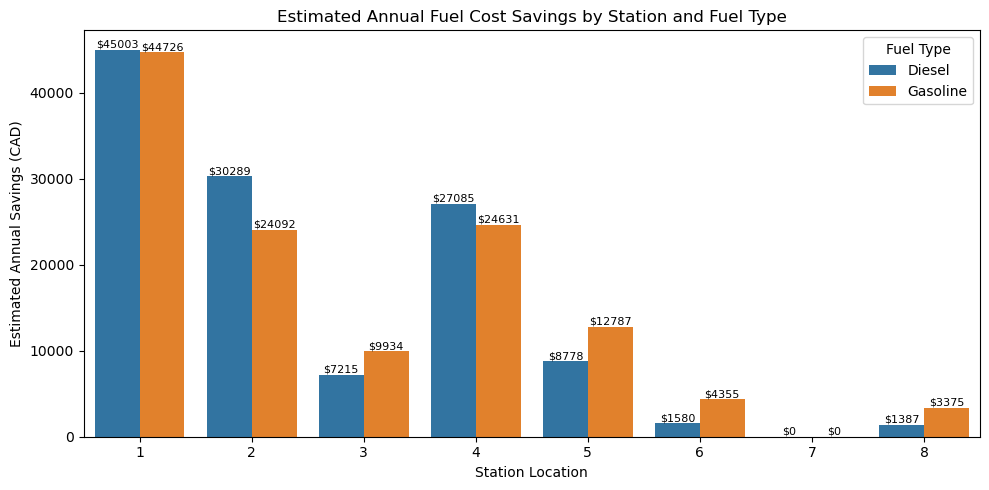

In [129]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=order_new, x='station_location', y='cost_diff', hue='tank_type2')
plt.title('Estimated Annual Fuel Cost Savings by Station and Fuel Type')
plt.xlabel('Station Location')
plt.ylabel('Estimated Annual Savings (CAD)')
plt.legend(title='Fuel Type')
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', label_type='edge', fontsize=8)
plt.tight_layout()
plt.show()

### 6.2 Optimal Day of Week to Purchase Fuel

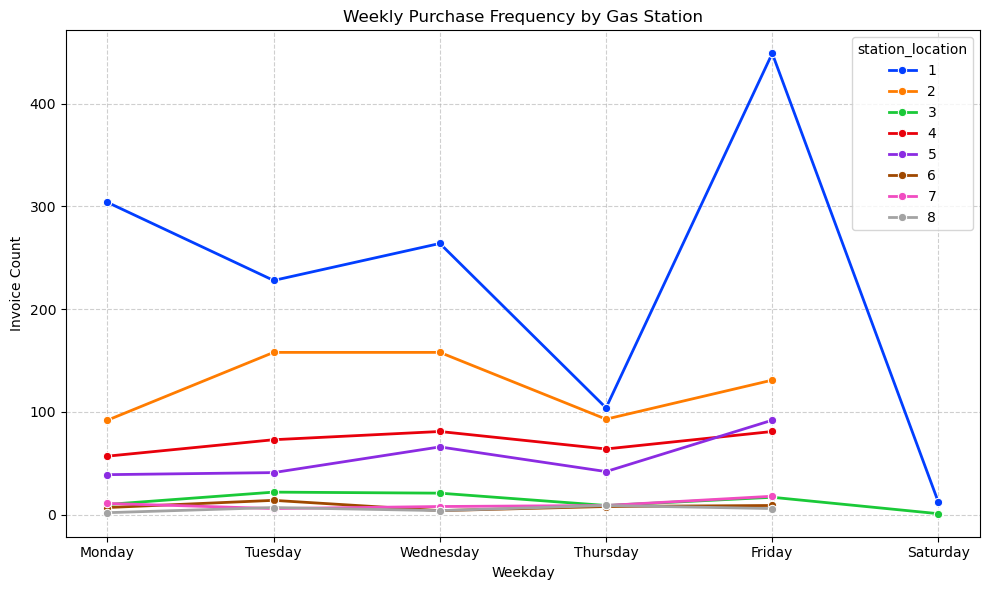

In [130]:
weekday_order   = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
station_weekday = invoices_df2.groupby(['station_location', 'Weekday']).size().reset_index(name='Count')
station_weekday['Weekday'] = pd.Categorical(station_weekday['Weekday'], categories=weekday_order, ordered=True)

plt.figure(figsize=(10, 6))
sns.lineplot(data=station_weekday, x='Weekday', y='Count', hue='station_location',
             palette='bright', marker='o', linewidth=2)
plt.title('Weekly Purchase Frequency by Gas Station')
plt.xlabel('Weekday')
plt.ylabel('Invoice Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

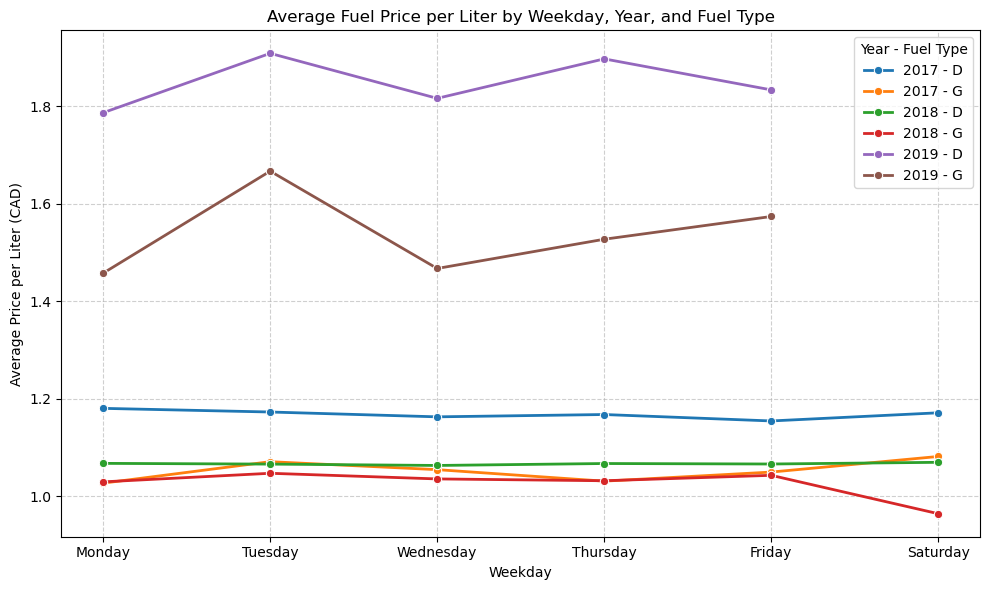

In [131]:
# Exclude Saturday (only 13 occurrences over 3 years — statistically insufficient)
invoice_df_withoutSaturday = invoices_df2[invoices_df2['Weekday'] != 'Saturday'].copy()
invoice_df_withoutSaturday['price_per_liter'] = (
    invoice_df_withoutSaturday['purchased_cost'] / invoice_df_withoutSaturday['purchased_amount'])

# Avg price per liter by weekday, year, fuel type (all days including Saturday)
Distribution_1 = invoices_df2.pivot_table(
    values='price_per_liter', index=['Year', 'tank_type1'], columns='Day_dig', aggfunc='mean')
Distribution_1.columns = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

Distribution_1_reset = Distribution_1.reset_index().melt(
    id_vars=['Year', 'tank_type1'], var_name='Weekday', value_name='Avg_Price_per_Liter')
Distribution_1_reset['Label'] = Distribution_1_reset['Year'].astype(str) + ' - ' + Distribution_1_reset['tank_type1']

plt.figure(figsize=(10, 6))
sns.lineplot(data=Distribution_1_reset, x='Weekday', y='Avg_Price_per_Liter',
             hue='Label', marker='o', linewidth=2)
plt.title('Average Fuel Price per Liter by Weekday, Year, and Fuel Type')
plt.xlabel('Weekday')
plt.ylabel('Average Price per Liter (CAD)')
plt.legend(title='Year - Fuel Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [132]:
# Avg price per liter by weekday, year, fuel type (excluding Saturday)
Distribution_of_price = invoice_df_withoutSaturday.pivot_table(
    values='price_per_liter', index=['Year', 'tank_type1'], columns='Day_dig', aggfunc='mean')
Distribution_of_price.columns = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
display(Distribution_of_price)

Monday  Tuesday  Wednesday  Thursday  Friday
Year tank_type1                                              
2017 D             1.18     1.17       1.16      1.17    1.15
     G             1.03     1.07       1.05      1.03    1.05
2018 D             1.07     1.07       1.06      1.07    1.07
     G             1.03     1.05       1.04      1.03    1.04
2019 D             1.79     1.91       1.82      1.90    1.83
     G             1.46     1.67       1.47      1.53    1.57

In [133]:
# Year-over-year price growth rate by weekday
Growth_Rate = Distribution_of_price.iloc[2:6, :].copy()
for i in range(4):
    for j in range(5):
        Growth_Rate.iloc[i, j] = ((Distribution_of_price.iloc[i + 2, j] - Distribution_of_price.iloc[i, j])
                                  / Distribution_of_price.iloc[i, j])
display(Growth_Rate)

Monday  Tuesday  Wednesday  Thursday  Friday
Year tank_type1                                              
2018 D            -0.10    -0.09      -0.09     -0.09   -0.08
     G             0.00    -0.02      -0.02      0.00   -0.01
2019 D             0.67     0.79       0.71      0.78    0.72
     G             0.42     0.59       0.42      0.48    0.51

### 6.3 Additional Savings from Timing Orders to the Cheapest Weekday

In [134]:
actual_total_cost = invoices_df2.pivot_table(
    values='purchased_cost', index=['Year', 'tank_type1'], columns='station_location', aggfunc='sum')
display(actual_total_cost)

Lowest_Day          = Distribution_of_price.idxmin(axis=1).rename('Weekday').to_frame()
Lowest_Day['Price'] = Distribution_of_price.min(axis=1)
display(Lowest_Day)

actual_purchase = invoices_df2.pivot_table(
    values='purchased_amount', index=['Year', 'tank_type1'], columns='station_location', aggfunc='sum')
actual_purchase['ideal_price_per_liter'] = Lowest_Day['Price']
display(actual_purchase)

ideal_total_cost = actual_purchase.iloc[:, :8].copy()
for i in range(6):
    ideal_total_cost.iloc[i, :8] = actual_purchase.iloc[i, :8] * actual_purchase.iloc[i, 8]
display(ideal_total_cost)

cost_difference = actual_total_cost.subtract(ideal_total_cost)
display(cost_difference)

station_location          1          2         3         4         5  \
Year tank_type1                                                        
2017 D           2282132.84 1747227.91 217827.63 685647.53 377492.44   
     G           4844086.97 1292876.50 245688.25 623756.07 593340.31   
2018 D           2238895.89 1702109.61 202496.72 795765.10 368793.57   
     G           4749693.99 1305788.54 146752.77 721434.79 543357.75   
2019 D           1375530.93  566210.27  72653.37 486148.85 248394.82   
     G           2708612.27  441337.17  54888.44 385581.86 350990.79   

station_location         6        7        8  
Year tank_type1                               
2017 D            25396.32  3955.75 43350.52  
     G           185053.55 31967.79 83309.30  
2018 D            26611.43  6825.09 26630.36  
     G           153339.39 44285.51 90690.85  
2019 D            14009.80  2415.09 17503.74  
     G            81363.60 27906.04 58598.15

Weekday  Price
Year tank_type1                  
2017 D              Friday   1.15
     G              Monday   1.03
2018 D           Wednesday   1.06
     G              Monday   1.03
2019 D              Monday   1.79
     G              Monday   1.46

station_location          1          2         3         4         5  \
Year tank_type1                                                        
2017 D           1989594.99 1516858.16 188074.51 602359.78 324889.60   
     G           4559836.38 1244200.59 237274.72 604630.56 573679.18   
2018 D           2102321.31 1594656.85 189560.61 746847.86 345018.10   
     G           4489192.96 1268268.18 143116.72 700341.31 528261.62   
2019 D            780541.73  349384.80  54180.00 283260.80 141826.26   
     G           1817181.87  310045.01  43127.22 273645.90 244772.02   

station_location         6        7        8  ideal_price_per_liter  
Year tank_type1                                                      
2017 D            21753.57  3554.85 41262.29                   1.15  
     G           178205.57 31823.54 79396.91                   1.03  
2018 D            25196.13  6367.10 25182.00                   1.06  
     G           148720.94 42936.18 87537.30                   1.03  
2019 D             7680.26  1160.32  9606.54                   1.79  
     G            59753.58 18803.10 40808.30                   1.46

station_location          1          2         3         4         5  \
Year tank_type1                                                        
2017 D           2297587.08 1751669.92 217188.71 695605.91 375182.96   
     G           4683955.03 1278067.71 243733.33 621088.59 589294.72   
2018 D           2235797.97 1695901.82 201595.84 794265.32 366923.34   
     G           4623046.93 1306084.05 147384.02 721223.34 544012.76   
2019 D           1394973.06  624415.54  96829.72 506239.67 253469.86   
     G           2649426.13  452041.35  62878.89 398971.96 356874.23   

station_location         6        7        8  
Year tank_type1                               
2017 D            25121.05  4105.14 47649.75  
     G           183056.32 32689.77 81558.09  
2018 D            26795.83  6771.35 26780.81  
     G           153155.35 44216.40 90147.39  
2019 D            13726.04  2073.71 17168.68  
     G            87119.90 27414.67 59497.94

station_location         1         2         3         4        5        6  \
Year tank_type1                                                              
2017 D           -15454.24  -4442.01    638.92  -9958.38  2309.48   275.26   
     G           160131.94  14808.80   1954.92   2667.48  4045.59  1997.23   
2018 D             3097.92   6207.79    900.89   1499.78  1870.23  -184.40   
     G           126647.05   -295.51   -631.25    211.45  -655.01   184.04   
2019 D           -19442.13 -58205.27 -24176.35 -20090.82 -5075.05   283.76   
     G            59186.14 -10704.18  -7990.44 -13390.09 -5883.44 -5756.30   

station_location       7        8  
Year tank_type1                    
2017 D           -149.39 -4299.23  
     G           -721.98  1751.21  
2018 D             53.74  -150.45  
     G             69.11   543.46  
2019 D            341.38   335.06  
     G            491.38  -899.80

## 7. Summary Statistics

In [135]:
display(invoices_df2.describe())

,invoice_date,invoice_id,station_location,purchased_cost,purchased_amount,Year,Month,Day,Day_dig,price_per_liter,disc_per_liter,disc_total
count,2831,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00
mean,2018-04-09 13:01:48.089014528,11415.00,2.31,11762.18,10270.82,2017.82,5.92,15.39,2.14,1.21,0.00,72.76
min,2017-01-02 00:00:00,10000.00,1.00,94.64,96.98,2017.00,1.00,1.00,0.00,0.88,0.00,0.00
25%,2017-08-09 00:00:00,10707.50,1.00,8327.90,7073.38,2017.00,3.00,8.00,1.00,1.02,0.00,0.00
50%,2018-04-06 00:00:00,11415.00,2.00,10459.09,9262.30,2018.00,6.00,15.00,2.00,1.06,0.00,0.00
75%,2018-11-28 00:00:00,12122.50,4.00,12518.35,11435.98,2018.00,8.00,23.00,4.00,1.22,0.00,0.00
max,2019-08-15 00:00:00,12830.00,8.00,33118.55,33826.56,2019.00,12.00,31.00,5.00,3.24,0.03,1014.80
std,NaN,817.38,1.69,6562.63,6101.91,0.76,3.31,8.83,1.49,0.34,0.01,221.31
